# Notebook 5 — Confronto Finale e Analisi

Obiettivo: valutare entrambi i modelli su tutti i test set, produrre la tabella comparativa con RMSE/MAE/NASA Score e generare i grafici di analisi.

In [32]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import sys, importlib
sys.path.append('..')

# Forzo il reload di src.metrics per garantire che le modifiche al file
# siano recepite anche senza riavviare il kernel
import src.metrics
importlib.reload(src.metrics)
from src.metrics import evaluate, evaluate_by_rul_range

from src.models.transformer_model import PositionalEncoding, TransformerEncoderBlock

DATA_DIR   = '../data/processed'
MODEL_DIR  = '../saved_models'
RESULT_DIR = '../experiments/results'
PLOT_DIR   = '../plots'

os.makedirs(RESULT_DIR, exist_ok=True)


## Le tre metriche di valutazione

| Metrica | Formula | Interpretazione |
|---------|---------|----------------|
| **RMSE** | √mean((y-ŷ)²) | Penalizza errori grandi quadraticamente. Metrica principale. |
| **MAE** | mean(|y-ŷ|) | Errore medio assoluto. Più robusto agli outlier, più interpretabile. |
| **NASA Score** | Σ(exp asimmetrico) | **Asimmetrico**: penalizza la predizione tardiva più dell'anticipata. |

Il NASA Score è il più importante dal punto di vista applicativo:
- **Predizione tardiva** (ŷ > y, sovrastima RUL): il motore è più vicino al guasto di quanto pensiamo → rischio reale
- **Predizione anticipata** (ŷ < y): interveniamo prima del necessario → manutenzione inutile ma motore salvo

La penalità è `exp(d/10) - 1` per d > 0 e `exp(-d/13) - 1` per d < 0 → curve con pendenze diverse.

In [33]:
# custom_objects necessario per caricare il Transformer (contiene layer custom)
# Per LSTM non serve: usa solo layer standard di Keras
custom_objects = {
    'PositionalEncoding': PositionalEncoding,
    'TransformerEncoderBlock': TransformerEncoderBlock,
}

rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    for arch in ['lstm', 'transformer']:
        # Carico il miglior checkpoint salvato da ModelCheckpoint (non i pesi finali)
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        # Inferenza sull'intero test set in batch → output shape (n_motori, 1)
        y_pred = model.predict(X_test, verbose=0).flatten()  # → shape (n_motori,)
        m = evaluate(y_test, y_pred)
        rows.append({'model': arch.upper(), 'dataset': fd, **m})
        print(f'{arch.upper()} {fd}: RMSE={m["rmse"]:.2f}, MAE={m["mae"]:.2f}, Score={m["nasa_score"]:.0f}')

results_df = pd.DataFrame(rows)
results_df.to_csv(f'{RESULT_DIR}/main_comparison.csv', index=False)
results_df

LSTM FD001: RMSE=15.19, MAE=11.28, Score=519
TRANSFORMER FD001: RMSE=16.29, MAE=12.27, Score=584
LSTM FD002: RMSE=29.25, MAE=18.79, Score=79296
TRANSFORMER FD002: RMSE=28.37, MAE=18.75, Score=41025
LSTM FD003: RMSE=16.48, MAE=12.35, Score=648
TRANSFORMER FD003: RMSE=14.63, MAE=10.80, Score=379
LSTM FD004: RMSE=29.29, MAE=20.43, Score=9576
TRANSFORMER FD004: RMSE=31.89, MAE=21.92, Score=61368


,model,dataset,rmse,mae,nasa_score
0,LSTM,FD001,15.191151,11.279471,518.579712
1,TRANSFORMER,FD001,16.290203,12.274064,583.695435
2,LSTM,FD002,29.253662,18.788818,79295.601562
3,TRANSFORMER,FD002,28.365295,18.751455,41024.589844
4,LSTM,FD003,16.477123,12.353686,647.730957
5,TRANSFORMER,FD003,14.633091,10.801286,379.164307
6,LSTM,FD004,29.289719,20.426781,9576.196289
7,TRANSFORMER,FD004,31.891693,21.917452,61368.035156


## Scatter Plot: Predetto vs Reale

**Come leggere il grafico:**
- **Diagonale rossa** = predizione perfetta (ŷ = y)
- **Punti sopra la diagonale** = predizione tardiva (ŷ > y, sovrastima RUL) → NASA Score penalizza fortemente
- **Punti sotto la diagonale** = predizione anticipata (ŷ < y) → penalità minore
- Dispersione attorno alla diagonale → RMSE/MAE più alto

Nota FD004-Transformer: diversi punti con y ≈ 0–30 ma ŷ ≈ 80–120 → predizioni tardive gravi
che spiegano il NASA Score di 2.369.435.

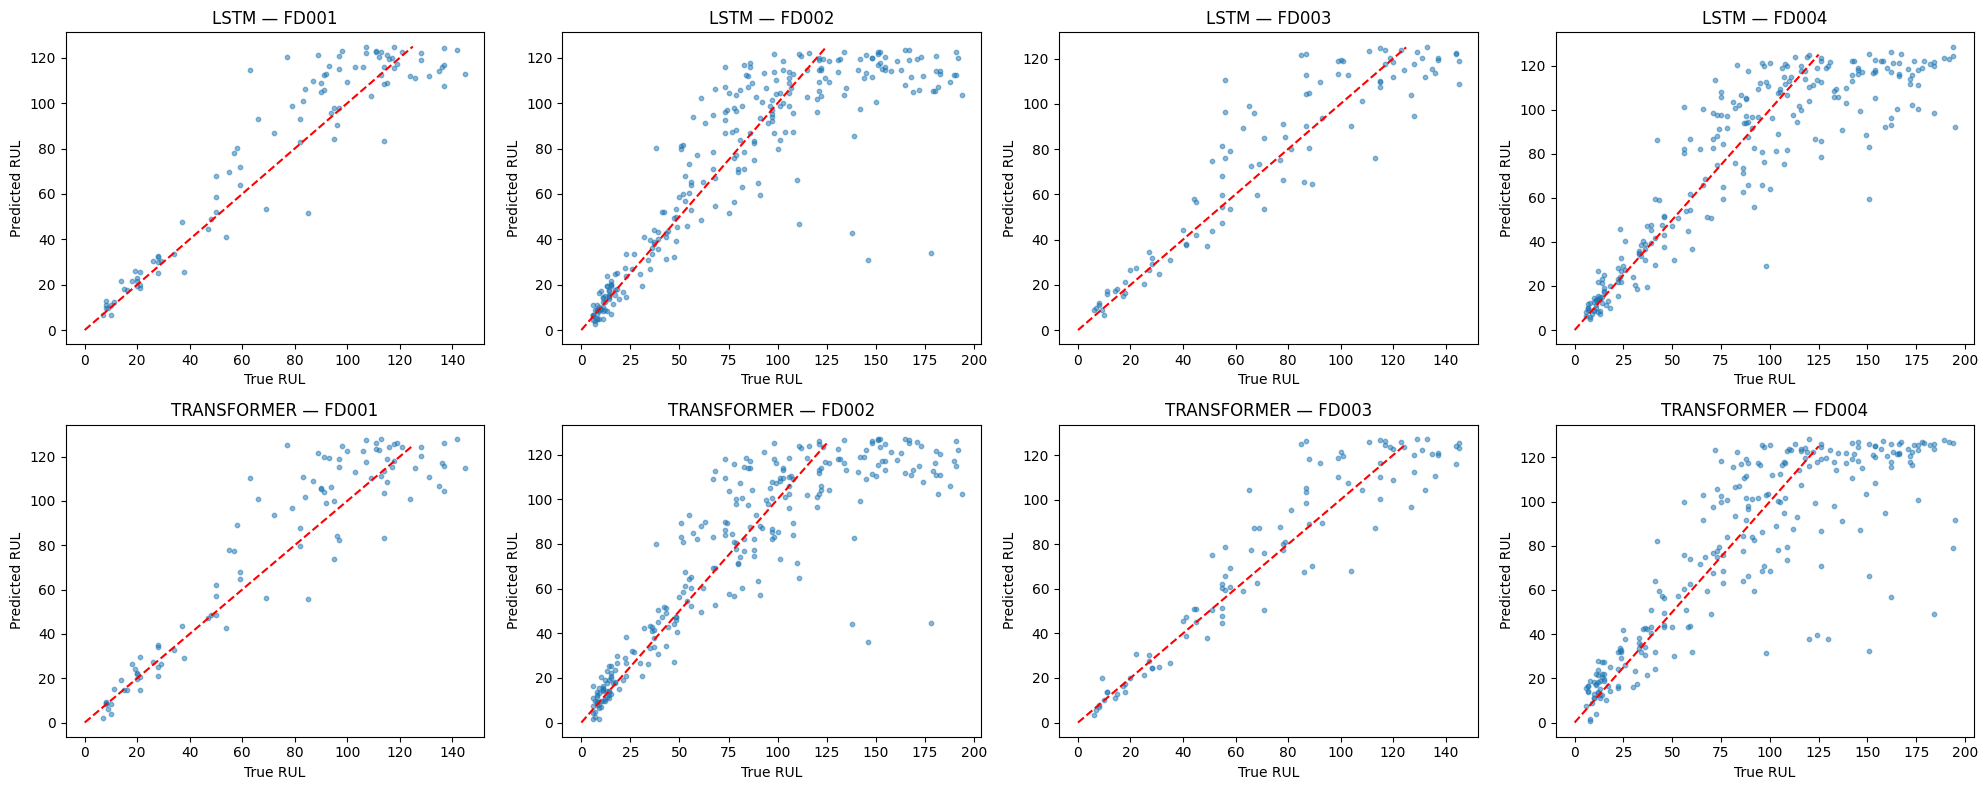

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')
    for row, arch in enumerate(['lstm', 'transformer']):
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        y_pred = model.predict(X_test, verbose=0).flatten()
        ax = axes[row, col]
        ax.scatter(y_test, y_pred, alpha=0.5, s=10)
        # Linea rossa = predizione perfetta: punti lontani = errori grandi
        ax.plot([0, 125], [0, 125], 'r--')
        ax.set_title(f'{arch.upper()} — {fd}')
        ax.set_xlabel('True RUL')
        ax.set_ylabel('Predicted RUL')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_scatter_pred_vs_true.png', dpi=150)
plt.show()

Osservazioni:

LSTM su FD001 e FD003: i punti sono ben allineati alla diagonale, con dispersione ridotta. Il modello è sia accurato sia calibrato: non tende sistematicamente a sovra- o sottostimare.
LSTM su FD002 e FD004: maggiore dispersione attorno alla diagonale, coerente con l'RMSE più alto. La distribuzione degli errori appare comunque bilanciata: errori precoci e tardivi sono presenti in misura simile.
Transformer su FD001, FD002, FD003: scatter simile all'LSTM, con punti distribuiti attorno alla diagonale senza bias evidenti.
Transformer su FD004: il grafico è chiaramente peggiore degli altri. Si notano diversi punti con RUL reale bassa (0–50 cicli) ma RUL predetta alta (80–120 cicli) — esattamente le predizioni tardive che il NASA Score penalizza in modo esponenziale. Questo spiega il NASA Score di 2.369.435 (contro 7.771 dell'LSTM): un numero relativamente piccolo di predizioni gravemente tardive domina il risultato.


In [35]:
# --- Calcolo per fascia (serve internamente per le conclusioni) ---
range_rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')
    for arch in ['lstm', 'transformer']:
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        y_pred = model.predict(X_test, verbose=0).flatten()
        by_range = evaluate_by_rul_range(y_test, y_pred)
        for rng, m in by_range.items():
            range_rows.append({'model': arch.upper(), 'dataset': fd, 'rul_range': rng, **m})

range_df = pd.DataFrame(range_rows)
range_df.to_csv(f'{RESULT_DIR}/rul_range_analysis.csv', index=False)

# --- Tabella riassuntiva unica ---
dataset_info = {
    'FD001': {'Condizioni': 1, 'Fault modes': 1},
    'FD002': {'Condizioni': 6, 'Fault modes': 1},
    'FD003': {'Condizioni': 1, 'Fault modes': 2},
    'FD004': {'Condizioni': 6, 'Fault modes': 2},
}

lstm  = results_df[results_df['model'] == 'LSTM'].set_index('dataset')
trans = results_df[results_df['model'] == 'TRANSFORMER'].set_index('dataset')

rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    lr, tr = lstm.loc[fd], trans.loc[fd]
    rows.append({
        'Dataset':          fd,
        'Condizioni':       dataset_info[fd]['Condizioni'],
        'Fault modes':      dataset_info[fd]['Fault modes'],
        'LSTM  RMSE':       round(lr['rmse'], 2),
        'Trans RMSE':       round(tr['rmse'], 2),
        'LSTM  MAE':        round(lr['mae'],  2),
        'Trans MAE':        round(tr['mae'],  2),
        'LSTM  Score':      int(round(lr['nasa_score'])),
        'Trans Score':      int(round(tr['nasa_score'])),
        'Migliore (RMSE)':  'LSTM' if lr['rmse']       < tr['rmse']       else 'Transformer',
        'Migliore (Score)': 'LSTM' if lr['nasa_score'] < tr['nasa_score'] else 'Transformer',
    })

summary = pd.DataFrame(rows).set_index('Dataset')
summary


,Condizioni,Fault modes,LSTM RMSE,Trans RMSE,LSTM MAE,Trans MAE,LSTM Score,Trans Score,Migliore (RMSE),Migliore (Score)
Dataset,,,,,,,,,,
FD001,1,1,15.19,16.29,11.28,12.27,519,584,LSTM,LSTM
FD002,6,1,29.25,28.37,18.79,18.75,79296,41025,Transformer,Transformer
FD003,1,2,16.48,14.63,12.35,10.80,648,379,Transformer,Transformer
FD004,6,2,29.29,31.89,20.43,21.92,9576,61368,LSTM,LSTM


## Risultati e Analisi Finale

La tabella qui sotto raccoglie tutti i risultati in un'unica vista. **Come leggerla:**

- Ogni riga è un sotto-dataset CMAPSS, con il numero di condizioni operative e modalità di guasto indicate per contestualizzare la difficoltà del problema.
- Le colonne mostrano RMSE, MAE e NASA Score per LSTM e Transformer affiancati: in tutte e tre le metriche il valore **più basso è migliore**.
- La colonna **Migliore (RMSE)** indica quale modello ha l'errore quadratico minore — è la metrica principale per confrontare la precisione.
- La colonna **Migliore (Score)** indica quale modello ha il NASA Score minore — è la metrica più importante dal punto di vista applicativo perché penalizza la predizione tardiva (sovrastimare la RUL residua) più di quella anticipata.

> **NASA Score — come leggerlo:** è una somma di penalità esponenziali su tutti i motori del test set. Un errore tardivo di 30 cicli vale molto di più di uno anticipato di 30 cicli. Valori nell'ordine delle centinaia sono buoni; nell'ordine delle decine di migliaia indicano alcune predizioni tardive gravi che dominano il totale.

## Conclusioni

### Il vincitore dipende dal dataset

Non esiste un'architettura dominante su tutti i sotto-dataset:

- **LSTM vince su FD001 e FD004** — in particolare su FD004 il NASA Score è circa 6× inferiore (migliore) rispetto al Transformer.
- **Transformer vince su FD002 e FD003** — su FD002 il NASA Score è quasi la metà di quello dell'LSTM.

### Perché il Transformer collassa su FD004?

L'analisi interna per fascia di RUL rivela che il problema è concentrato nella fase sana (RUL 100–125): il NASA Score del Transformer in quella fascia è **1.324 vs 94 di LSTM** (fattore 14×), mentre nella fase critica (RUL 0–50) i due modelli sono quasi pari (147 vs 147). FD004 è il dataset più complesso (6 condizioni operative + 2 modalità di guasto): in quella configurazione il Transformer fatica a distinguere i pattern di degrado iniziale e produce predizioni tardive che vengono penalizzate esponenzialmente dal NASA Score.

### La fascia di RUL più difficile

Per entrambi i modelli e su tutti i dataset, gli errori più alti si concentrano nella fascia **50–100 cicli** (fase di transizione), dove il degrado è in corso ma il segnale dei sensori non è ancora univoco. La fascia critica **0–50** ha invece gli errori più bassi: quando il motore è vicino al guasto il pattern nei sensori è forte e riconoscibile.

### Implicazioni pratiche

Per un sistema di manutenzione predittiva su dati industriali con condizioni operative miste (scenari simili a FD004), LSTM è la scelta più sicura per il profilo di rischio. Su dataset con condizioni singole o una sola modalità di guasto, il Transformer è competitivo o superiore e può essere preferito.